# Behavior analysis smoke test (archived)

Check that source trial data loads, computed tables populate, and the resulting plots look reasonable.

Requires labdata/DataJoint credentials and the project `.venv` kernel.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
for path in (REPO_ROOT / "src", REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from behavior_analyses.psychometrics import cumulative_gaussian
from labdata.schema import DecisionTask
from labdata_plugin.analysisschema import (
    BehaviorSessionSet,
    LearningSessionMetrics,
    PsychometricSessionFit,
    PsychometricSubjectFit,
    PsychophysicalKernel,
)

SESSION_SET_ID = "migration_stress_test"
SESSION_SET_NAME = "Migration stress test"
SUBJECT_TRIALSETS = {
    "GRB006": "visual+audio",
    "GRB026": "visual",
}
MIN_TRIALS_WITH_CHOICE = 100
PERFORMANCE_THRESHOLD = 0.7

SEED_IF_MISSING = True
POPULATE = True

In [9]:
from labdata.schema import *

## 1. Source data and session set

In [2]:
source = DecisionTask.TrialSet() & [
    {"subject_name": subject, "trialset_description": trialset}
    for subject, trialset in SUBJECT_TRIALSETS.items()
]
source = source & f"n_with_choice >= {MIN_TRIALS_WITH_CHOICE}"
source = source & f"performance_easy >= {PERFORMANCE_THRESHOLD}"

preview_cols = [
    "subject_name",
    "session_name",
    "trialset_description",
    "n_trials",
    "n_with_choice",
    "performance_easy",
]
source_rows = source.fetch(as_dict=True, limit=20)
print(f"matching source trialsets: {len(source)}")
if source_rows:
    display(pd.DataFrame(source_rows)[preview_cols])
else:
    raise ValueError(
        "No source trialsets matched. Check SUBJECT_TRIALSETS and thresholds."
    )

key = {"session_set_id": SESSION_SET_ID}
session_set_exists = len(BehaviorSessionSet & key) > 0
parts_empty = session_set_exists and len(BehaviorSessionSet.TrialSet & key) == 0
print("session set exists:", session_set_exists)
print("session set parts empty:", parts_empty)

if not session_set_exists or parts_empty:
    if not SEED_IF_MISSING:
        raise ValueError("Set SEED_IF_MISSING=True to create or fill the session set.")
    from collections import Counter

    trialset_keys = source.fetch("KEY")
    if not trialset_keys:
        raise ValueError("Refusing to seed an empty session set.")

    session_rows = {
        (row["subject_name"], row["session_name"]): {
            "session_set_id": SESSION_SET_ID,
            "subject_name": row["subject_name"],
            "session_name": row["session_name"],
            "include_reason": "notebook_seed",
        }
        for row in trialset_keys
    }
    subject_trialset_rows = [
        {
            "session_set_id": SESSION_SET_ID,
            "subject_name": subject,
            "trialset_description": trialset,
            "n_sessions": count,
        }
        for (subject, trialset), count in Counter(
            (row["subject_name"], row["trialset_description"]) for row in trialset_keys
        ).items()
    ]
    if not session_set_exists:
        BehaviorSessionSet.insert1(
            {
                **key,
                "session_set_name": SESSION_SET_NAME,
                "performance_threshold": PERFORMANCE_THRESHOLD,
                "min_trials_with_choice": MIN_TRIALS_WITH_CHOICE,
                "kernel_timebins": 10,
                "kernel_cv_splits": 10,
                "kernel_random_state": 0,
                "analysis_version": "v1",
            },
            skip_duplicates=True,
        )
    BehaviorSessionSet.Session.insert(
        list(session_rows.values()), skip_duplicates=True, ignore_extra_fields=True
    )
    BehaviorSessionSet.TrialSet.insert(
        [
            {**row, "session_set_id": SESSION_SET_ID, "include_reason": "notebook_seed"}
            for row in trialset_keys
        ],
        skip_duplicates=True,
        ignore_extra_fields=True,
    )
    BehaviorSessionSet.SubjectTrialSet.insert(
        subject_trialset_rows, skip_duplicates=True, ignore_extra_fields=True
    )
    print("seeded session set")

display(
    pd.Series(
        {
            "sessions": len(BehaviorSessionSet.Session & key),
            "trialsets": len(BehaviorSessionSet.TrialSet & key),
            "subject_trialsets": len(BehaviorSessionSet.SubjectTrialSet & key),
        },
        name="session_set_parts",
    )
)

matching source trialsets: 183


,subject_name,session_name,trialset_description,n_trials,n_with_choice,performance_easy
0,GRB006,20230825_164150,visual+audio,172,156,0.750000
1,GRB006,20230828_121451,visual+audio,218,169,0.721893
2,GRB006,20230830_153320,visual+audio,255,220,0.704545
3,GRB006,20230907_130602,visual+audio,411,190,0.784211
4,GRB006,20230908_145401,visual+audio,292,113,0.858407
5,GRB006,20230911_135336,visual+audio,314,120,0.816667
6,GRB006,20230913_120155,visual+audio,274,116,0.870690
7,GRB006,20230915_142428,visual+audio,383,127,0.952756
8,GRB006,20230920_155219,visual+audio,307,120,0.797101
9,GRB006,20230921_133636,visual+audio,304,134,0.967213


session set exists: True
session set parts empty: False


sessions             183
trialsets            183
subject_trialsets      2
Name: session_set_parts, dtype: int64

## 2. Populate computed tables

In [3]:
computed_tables = [
    LearningSessionMetrics,
    PsychometricSessionFit,
    PsychometricSubjectFit,
    PsychophysicalKernel,
]

status = {}
for table in computed_tables:
    pending = (table.key_source & key) - table()
    status[table.__name__] = {"rows": len(table & key), "pending": len(pending)}
    if POPULATE and len(pending):
        print(f"populating {table.__name__} ({len(pending)} pending)")
        table.populate(key, display_progress=True)
        status[table.__name__]["rows"] = len(table & key)
        status[table.__name__]["pending"] = len((table.key_source & key) - table())

display(pd.DataFrame(status).T.astype({"rows": int, "pending": int}))

populating PsychometricSessionFit (56 pending)


PsychometricSessionFit: 100%|████████████████████████████████████████████████████████| 56/56 [00:06<00:00,  9.21it/s]


,rows,pending
LearningSessionMetrics,183,0
PsychometricSessionFit,127,56
PsychometricSubjectFit,2,0
PsychophysicalKernel,2,0


## 3. Quick look at computed rows

In [4]:
learning_rows = (LearningSessionMetrics & key).fetch(as_dict=True)
psych_rows = (PsychometricSubjectFit & key).fetch(as_dict=True)
kernel_rows = (PsychophysicalKernel & key).fetch(as_dict=True)

print({
    "learning_sessions": len(learning_rows),
    "psychometric_subjects": len(psych_rows),
    "kernels": len(kernel_rows),
})

if learning_rows:
    display(
        pd.DataFrame(learning_rows)[
            ["subject_name", "session_name", "n_trials", "n_with_choice", "performance", "performance_easy"]
        ].sort_values(["subject_name", "session_name"])
    )

if psych_rows:
    display(
        pd.DataFrame([
            {k: v for k, v in row.items() if k not in {"stims", "p_right", "p_right_ci", "fit_params", "p_side", "p_side_ci", "n_side", "n_obs", "n_right"}}
            for row in psych_rows
        ])
    )

{'learning_sessions': 183, 'psychometric_subjects': 2, 'kernels': 2}


,subject_name,session_name,n_trials,n_with_choice,performance,performance_easy
0,GRB006,20230825_164150,172,156,0.750000,0.750000
1,GRB006,20230828_121451,218,169,0.721893,0.721893
2,GRB006,20230830_153320,255,220,0.704545,0.704545
3,GRB006,20230907_130602,411,190,0.784211,0.784211
4,GRB006,20230908_145401,292,113,0.858407,0.858407
...,...,...,...,...,...,...
178,GRB026,20240729_105049,303,109,0.752294,0.823529
179,GRB026,20240730_112645,728,305,0.780328,0.870229
180,GRB026,20240731_111652,355,237,0.759494,0.888889
181,GRB026,20240731_123806,470,348,0.798851,0.902439


,session_set_id,subject_name,trialset_description,n_sessions,n_trials,bias,sensitivity,guess_rate,lapse_rate,goodness_of_fit
0,migration_stress_test,GRB006,visual+audio,130,57115,-0.551729,0.223799,0.079345,0.127026,0.992201
1,migration_stress_test,GRB026,visual,53,21981,-1.713460,0.196147,0.003748,0.113310,0.988667


## 4. Plots

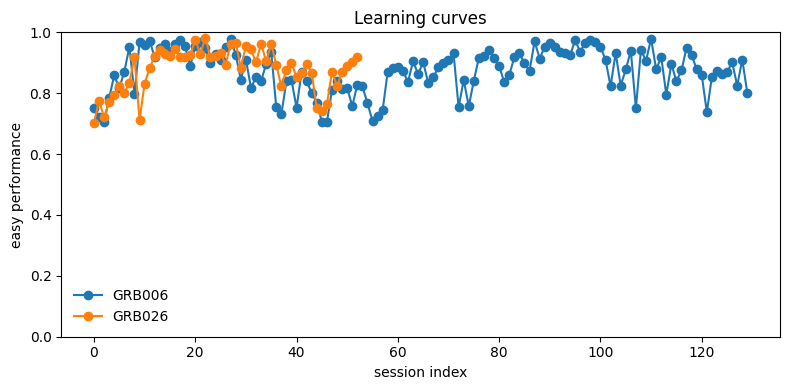

In [5]:
if learning_rows:
    data = pd.DataFrame(learning_rows).sort_values(["subject_name", "session_name"])
    fig, ax = plt.subplots(figsize=(8, 4))
    for subject, subject_df in data.groupby("subject_name"):
        ax.plot(subject_df["performance_easy"].to_numpy(), marker="o", label=subject)
    ax.set(xlabel="session index", ylabel="easy performance", ylim=(0, 1), title="Learning curves")
    ax.legend(frameon=False)
    fig.tight_layout()
else:
    print("no learning rows to plot")

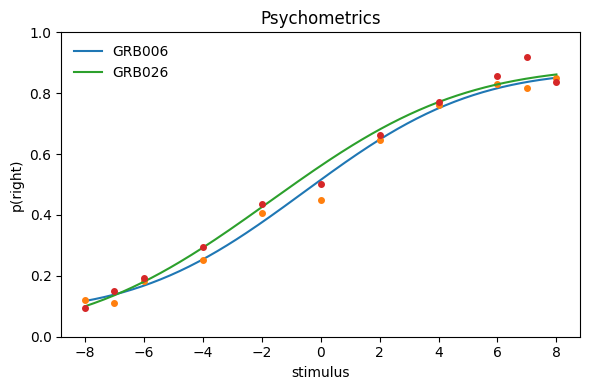

In [6]:
if psych_rows:
    fig, ax = plt.subplots(figsize=(6, 4))
    for row in psych_rows:
        stims = np.asarray(row["stims"], dtype=float)
        params = np.asarray(row["fit_params"], dtype=float)
        p_right = np.asarray(row["p_right"], dtype=float)
        x = np.linspace(stims.min(), stims.max(), 200)
        ax.plot(x, cumulative_gaussian(*params, x), label=row["subject_name"])
        ax.plot(stims, p_right, "o", ms=4)
    ax.set(xlabel="stimulus", ylabel="p(right)", ylim=(0, 1), title="Psychometrics")
    ax.legend(frameon=False)
    fig.tight_layout()
else:
    print("no psychometric rows to plot")

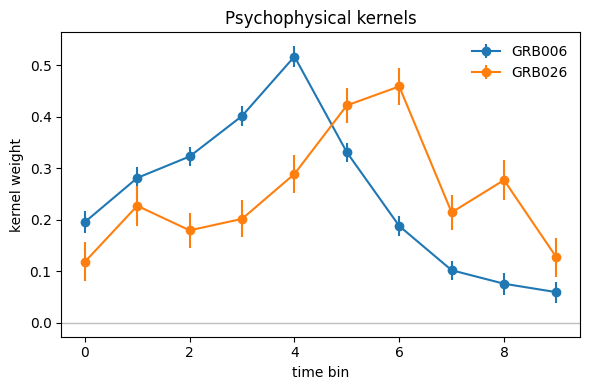

In [7]:
if kernel_rows:
    fig, ax = plt.subplots(figsize=(6, 4))
    for row in kernel_rows:
        weights = np.asarray(row["weights_mean"], dtype=float)
        error = np.asarray(row["weights_error"], dtype=float)
        x = np.arange(weights.size)
        ax.errorbar(
            x,
            weights,
            yerr=error,
            fmt="o-",
            label=row["subject_name"],
        )
    ax.axhline(0, color="0.75", linewidth=1)
    ax.set(xlabel="time bin", ylabel="kernel weight", title="Psychophysical kernels")
    ax.legend(frameon=False)
    fig.tight_layout()
else:
    print("no kernel rows to plot")